# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [82]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [83]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [84]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [85]:
type(registros)

list

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [87]:
dados = pd.DataFrame(registros)

dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [88]:
print(f'O dataset possui {dados.shape[0]} linhas e {dados.shape[1]} colunas')

O dataset possui 336 linhas e 11 colunas


In [89]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [90]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [91]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


O atributo din_referenciautc é refente a data/hora  
O atributo cod_areacarga é referente a area carga  
O atributo val_cargaglobal é referente a valor carga

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [92]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [93]:
dados.rename(columns={'cod_areacarga': 'area_carga',
                      'din_referenciautc': 'data_hora',
                      'val_cargaglobal': 'carga_global',
                      'val_cargaglobalsmmgd': 'carga_global_sem_mmgd',
                      'val_cargammgd': 'carga_global_mmgd'
                      }, inplace=True)

In [102]:
df = dados[['area_carga', 'data_hora', 'carga_global', 'carga_global_sem_mmgd', 'carga_global_mmgd']].copy()

df

,area_carga,data_hora,carga_global,carga_global_sem_mmgd,carga_global_mmgd
0,SP,2025-08-01T03:30:00.000Z,15913.618,15892.488,21.13
1,SP,2025-08-01T04:00:00.000Z,15251.414,15230.284,21.13
2,SP,2025-08-01T04:30:00.000Z,14606.733,14585.604,21.13
3,SP,2025-08-01T05:00:00.000Z,14182.290,14161.160,21.13
4,SP,2025-08-01T05:30:00.000Z,13838.488,13817.358,21.13
...,...,...,...,...,...
331,SP,2025-08-08T01:00:00.000Z,20930.443,20909.312,21.13
332,SP,2025-08-08T01:30:00.000Z,19936.190,19915.059,21.13
333,SP,2025-08-08T02:00:00.000Z,19153.877,19132.746,21.13
334,SP,2025-08-08T02:30:00.000Z,18149.570,18128.440,21.13


In [103]:
df.isna().sum()

,0
area_carga,0
data_hora,0
carga_global,0
carga_global_sem_mmgd,0
carga_global_mmgd,0


In [104]:
print(df['carga_global'].dtype)

print(df['carga_global'].head())

float64
0    15913.618
1    15251.414
2    14606.733
3    14182.290
4    13838.488
Name: carga_global, dtype: float64


In [105]:
print(df['data_hora'].head())

0    2025-08-01T03:30:00.000Z
1    2025-08-01T04:00:00.000Z
2    2025-08-01T04:30:00.000Z
3    2025-08-01T05:00:00.000Z
4    2025-08-01T05:30:00.000Z
Name: data_hora, dtype: object


In [106]:
df['data_hora'] = pd.to_datetime(df['data_hora'])

In [107]:
print(df['data_hora'].dtype)

datetime64[ns, UTC]


In [108]:
df['data_hora'].head()

,data_hora
0,2025-08-01 03:30:00+00:00
1,2025-08-01 04:00:00+00:00
2,2025-08-01 04:30:00+00:00
3,2025-08-01 05:00:00+00:00
4,2025-08-01 05:30:00+00:00


## Decisões de tratamento

Decidimos que os atributos mais importantes são: Código da Área da Carga, Data e Hora, Carga Global, Carga Global atendida por Micro e Minigeração Distribuída (MMGD) e Carga Global sem MMGD.

A seleção desses atributos permite uma análise completa e focada do perfil de consumo da cidade de São Paulo no período selecionado, evitando informações desnecessárias, facilitando a identificação de padrões, melhorando a qualidade dos indicadores e reduzindo a complexidade.

Como não há valores ausentes, não houve a necessidade de tratamento nesse aspecto.

Valores de carga já estavam em formato numérico e, portanto, não houve a necessidade de tratamento.

Decidimos converter a data do tipo Object para datetime64, o formato de data e hora do Pandas, para ter consistência de dados e maior facilidade de manipulação e análise por meio das ferramentas fornecidas pelo Pandas para o tipo.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [63]:
cargaMin = df['carga_global'].min()
cargaMax = df['carga_global'].max()
cargaMed = df['carga_global'].mean()
cargaMediana = df['carga_global'].median()
amplitude = cargaMax - cargaMin
qtdTotal = df['carga_global'].count()

In [64]:
print(f'A carga mínima é: {cargaMin}')
print(f'A carga máxima é: {cargaMax}')
print(f'A carga média é: {cargaMed}')
print(f'A carga mediana é: {cargaMediana}')
print(f'A amplitude entre máximo e mínimo é: {amplitude}')
print(f'A quantidade total de medições é: {qtdTotal}')

A carga mínima é: 12139.253
A carga máxima é: 23185.312
A carga média é: 17870.828980654762
A carga mediana é: 18199.1285
A amplitude entre máximo e mínimo é: 11046.059000000001
A quantidade total de medições é: 336


## Análise da Carga Máxima em Relação à Carga Média

Com base nos indicadores calculados:

- **Carga Máxima (`cargaMax`):** 23185.312 MW
- **Carga Média (`cargaMed`):** 17870.829 MW
- **Carga Mediana (`cargaMediana`):** 18199.1285 MW
- **Amplitude (`amplitude`):** 11046.059 MW

O valor da carga máxima (23185.312 MW) é significativamente superior à carga média (17870.829 MW) e à carga mediana (18199.1285 MW). A diferença entre a carga máxima e a carga média é de aproximadamente 5314.48 MW. Esta diferença representa cerca de 29.7% da carga média.

A amplitude total, que é a diferença entre a carga máxima e a carga mínima, é de 11046.059 MW. Considerando essa amplitude, a diferença entre a carga máxima e a média é considerável, indicando que o pico de carga está, de fato, um pouco distante do comportamento médio observado. Embora não seja um valor extremamente extremo (não está, por exemplo, o dobro da média), ele se destaca como um ponto de demanda significativamente mais alta, o que é comum em sistemas elétricos que experimentam picos de uso diários.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [65]:
limiarAltaDemanda = cargaMax * 0.90

df_altaDemanda = df[df['carga_global'] > limiarAltaDemanda]

qtdRegistros_df_altaDemanda = df_altaDemanda['carga_global'].count()

percentual_df_altaDemanda = (qtdRegistros_df_altaDemanda / qtdTotal) * 100

maiorCarga = df_altaDemanda['carga_global'].max()

dataHoraPico = df_altaDemanda.loc[df_altaDemanda['carga_global'].idxmax(), 'data_hora']

dataHoraPico

Timestamp('2025-08-01 22:00:00+0000', tz='UTC')

In [110]:
print(f'O limiar de alta demanda é: {limiarAltaDemanda}')

print(f'\nA quantidade de registros acima do limiar é: {qtdRegistros_df_altaDemanda}')
print(f'O percentual de registros acima do limiar é: {percentual_df_altaDemanda:.2f}%')

print(f'\nMaior carga registrada no período de alta demanda: {maiorCarga}')
print(f'Data e hora do pico: {dataHoraPico}')

O limiar de alta demanda é: 20866.7808

A quantidade de registros acima do limiar é: 50
O percentual de registros acima do limiar é: 14.88%

Maior carga registrada no período de alta demanda: 23185.312
Data e hora do pico: 2025-08-01 22:00:00+00:00


## Análise dos Períodos Próximos ao Pico

Com base nos indicadores calculados para os períodos de alta demanda (carga superior a 90% da carga máxima):

- **Limiar de Alta Demanda:** 20866.7808 MW
- **Quantidade de Registros em Alta Demanda:** 50
- **Percentual de Registros em Alta Demanda:** 14.88%
- **Maior Carga Registrada no Período de Alta Demanda:** 23185.312 MW
- **Data e Hora do Pico:** 2025-08-01 22:00:00+00:00

Os 50 registros que representam períodos de alta demanda correspondem a aproximadamente **14.88%** do total de 336 medições. Este percentual indica que os períodos próximos ao pico de demanda representam uma **parcela pequena, mas significativa**, do período total analisado. Isso é esperado, pois picos de carga são eventos pontuais e não representam o comportamento médio contínuo, mas são cruciais para o planejamento energético.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [67]:
df_acimaMedia = df[df['carga_global'] > cargaMed]

qtdRegistros_df_acimaMedia = df_acimaMedia['carga_global'].count()

percentual_df_acimaMedia = (qtdRegistros_df_acimaMedia / qtdTotal) * 100

In [118]:
print(f'O critério escolhido foi: carga acima da média')

##print(f'\nO novo DataFrame é: {df_acimaMedia}')
display(df_acimaMedia.head())

print(f'\nA quantidade de registros é: {qtdRegistros_df_acimaMedia}')
print(f'O percentual é: {percentual_df_acimaMedia:.2f}%')
print(f'\nComparação com o conjunto de alta demanda:')
print(f'\n- Percentual de registros com carga acima da média: {percentual_df_acimaMedia:.2f}%')
print(f'- Percentual de registros de alta demanda (90% da carga máxima): {percentual_df_altaDemanda:.2f}%')
print(f'\nO conjunto de "carga acima da média" representa uma parcela maior ({percentual_df_acimaMedia:.2f}%) do período total analisado em comparação com o conjunto de "alta demanda" ({percentual_df_altaDemanda:.2f}%).'
'\nIsso é esperado, pois o critério de "acima da média" é menos restritivo do que "acima de 90% da carga máxima".')

O critério escolhido foi: carga acima da média


,area_carga,data_hora,carga_global,carga_global_sem_mmgd,carga_global_mmgd
15,SP,2025-08-01 11:00:00+00:00,18096.023,17415.600,680.4232
16,SP,2025-08-01 11:30:00+00:00,18629.395,17409.600,1219.7958
17,SP,2025-08-01 12:00:00+00:00,18825.176,17097.592,1727.5842
18,SP,2025-08-01 12:30:00+00:00,19056.504,16850.477,2206.0276
19,SP,2025-08-01 13:00:00+00:00,19427.822,16792.590,2635.2324



A quantidade de registros é: 184
O percentual é: 54.76%

Comparação com o conjunto de alta demanda:

- Percentual de registros com carga acima da média: 54.76%
- Percentual de registros de alta demanda (90% da carga máxima): 14.88%

O conjunto de "carga acima da média" representa uma parcela maior (54.76%) do período total analisado em comparação com o conjunto de "alta demanda" (14.88%).
Isso é esperado, pois o critério de "acima da média" é menos restritivo do que "acima de 90% da carga máxima".


## Comparação entre os Critérios de Recorte dos Dados

Foram definidos dois critérios para a criação de subconjuntos de dados, cada um com suas características e implicações para a análise do comportamento da carga elétrica:

1.  **Alta Demanda (carga > 90% da carga máxima):**
    *   **Limiar:** `20866.78 MW`
    *   **Quantidade de Registros:** `50`
    *   **Percentual do Total:** `14.88%`
    *   Este critério é mais restritivo, focando nos momentos de pico extremo de demanda. Ele é útil para identificar situações críticas que exigem atenção especial no planejamento e operação do sistema elétrico. O baixo percentual de registros reflete a natureza esporádica desses eventos de pico.

2.  **Carga Acima da Média (carga > carga média):**
    *   **Carga Média:** `17870.83 MW`
    *   **Quantidade de Registros:** `184`
    *   **Percentual do Total:** `54.76%`
    *   Este critério é mais abrangente, incluindo todos os períodos em que a carga está acima do comportamento médio observado. Ele fornece uma visão mais ampla dos momentos de demanda elevada, que não são necessariamente picos extremos, mas representam um patamar de consumo significativamente maior que o usual. O percentual maior de registros é esperado, pois a média é um limiar mais baixo do que 90% da carga máxima.

### Conclusão da Comparação:

Ambos os critérios são válidos para a análise, mas servem a propósitos distintos. O critério de **Alta Demanda** isola os eventos mais críticos, essenciais para a avaliação de resiliência e capacidade do sistema em condições extremas. Já o critério de **Carga Acima da Média** oferece um panorama mais geral dos períodos de demanda elevada, sendo útil para entender padrões de consumo e identificar tendências mais consistentes ao longo do dia ou da semana. A combinação da análise de ambos os recortes oferece uma compreensão mais completa do perfil de carga da região.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

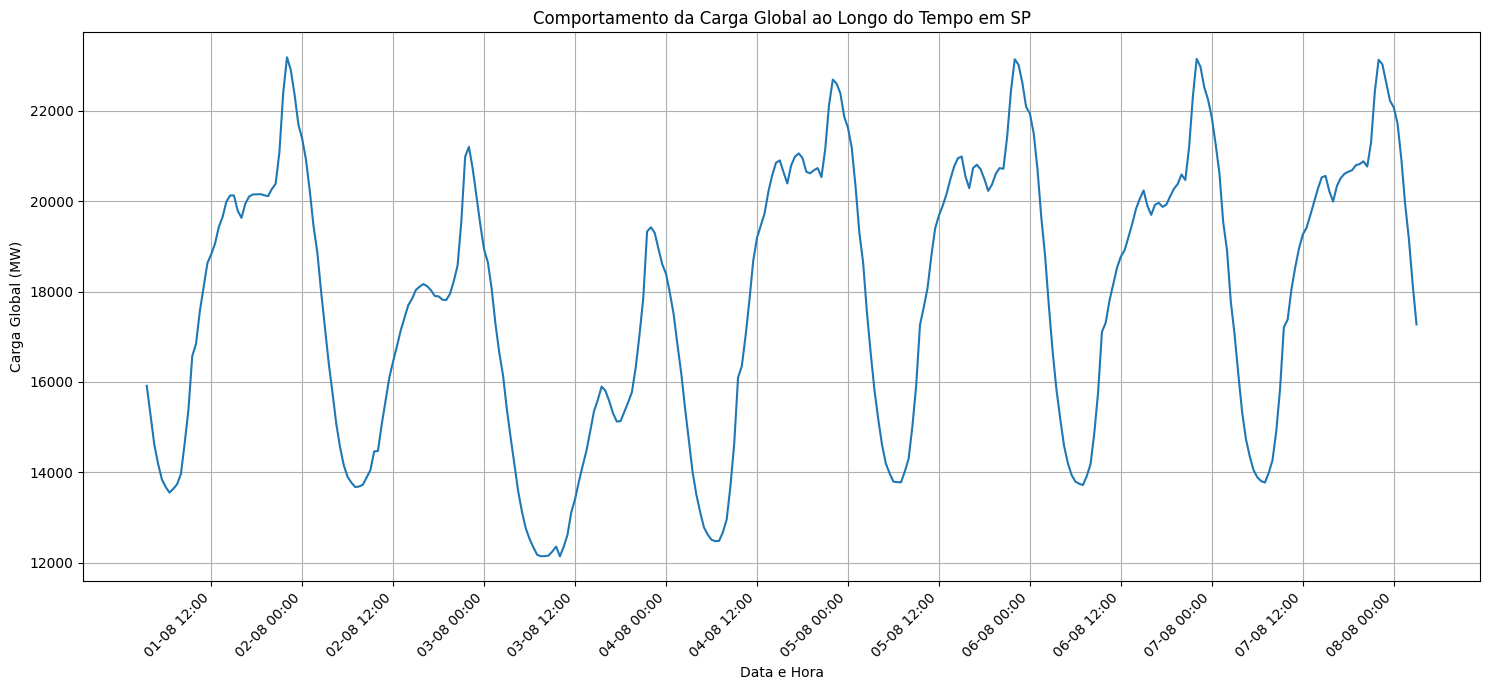

In [69]:
import matplotlib.dates as mdates

# Get the min and max datetimes from the 'data_hora' column
min_datetime = df['data_hora'].min()
max_datetime = df['data_hora'].max()

# Create a range of dates for the ticks, from the start of the first day to the end of the last day
# Adding a day to max_datetime.normalize() ensures the last day's 00:00 and 12:00 are considered.
date_ticks = pd.date_range(start=min_datetime.normalize(),
                           end=max_datetime.normalize() + pd.Timedelta(days=1),
                           freq='D')

custom_ticks = []
for d in date_ticks:
    # Add 00:00 and 12:00 for each day
    custom_ticks.append(d.replace(hour=0, minute=0))
    custom_ticks.append(d.replace(hour=12, minute=0))

# Filter custom_ticks to only include those strictly within the actual data range
custom_ticks = [t for t in custom_ticks if min_datetime <= t <= max_datetime]

plt.figure(figsize=(15, 7)) # Increase figure size for better readability
sns.lineplot(x='data_hora', y='carga_global', data=df)
plt.title('Comportamento da Carga Global ao Longo do Tempo em SP')
plt.xlabel('Data e Hora')
plt.ylabel('Carga Global (MW)')
plt.grid(True)

ax = plt.gca()
ax.set_xticks(custom_ticks) # Set custom ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M')) # Format to show Day-Month Hour:Minute
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Interpretação do Gráfico de Comportamento da Carga ao Longo do tempo.

 O gráfico mostra a variação da carga global ao longo da semana analisada. Podemos observar padrões diários e semanais, com picos e vales que provavelmente correspondem a horários de maior e menor consumo. Os picos de demanda, como o identificado anteriormente no dia 2025-08-01 22:00:00+00:00, são claramente visíveis, indicando momentos de alta exigência no sistema. A análise visual permite identificar tendências e anomalias que seriam mais difíceis de perceber apenas com dados tabulares, confirmando a natureza flutuante da demanda de energia.

/tmp/ipykernel_948/3706846890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora_do_dia'] = df['data_hora'].dt.hour


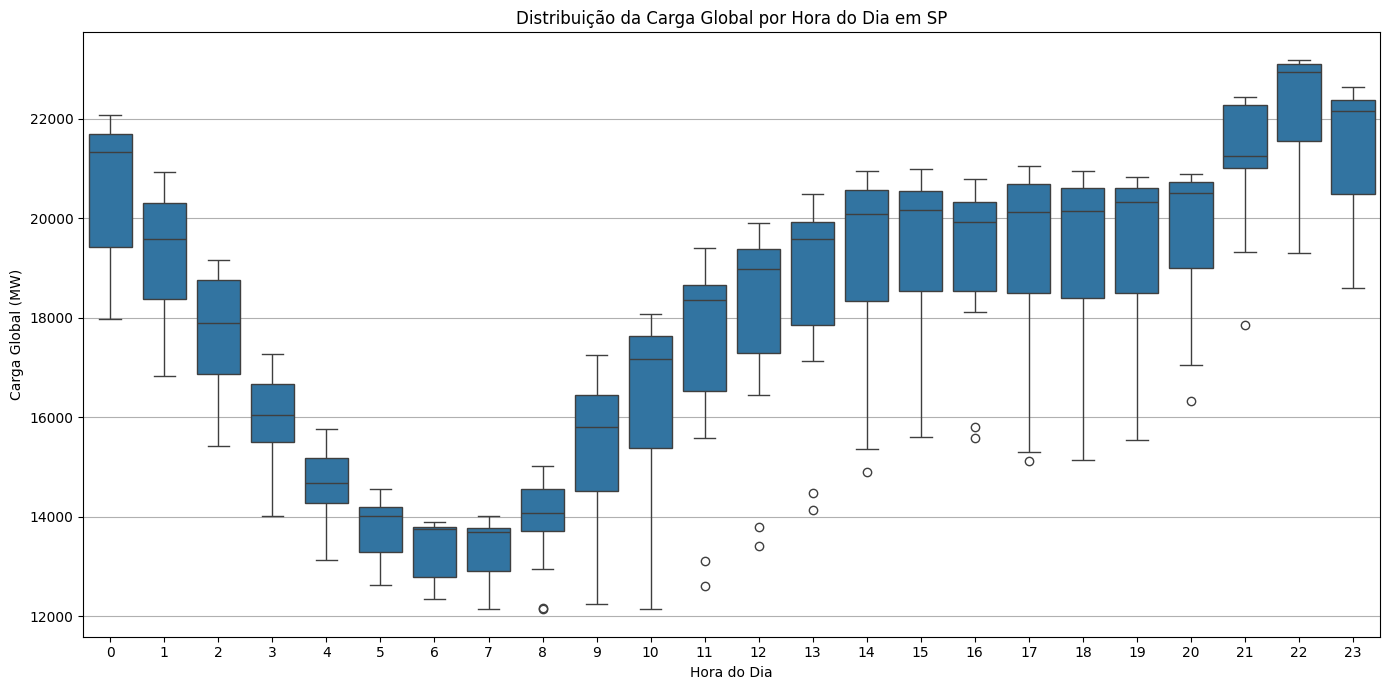

In [71]:
df['hora_do_dia'] = df['data_hora'].dt.hour

plt.figure(figsize=(14, 7))
sns.boxplot(x='hora_do_dia', y='carga_global', data=df)
plt.title('Distribuição da Carga Global por Hora do Dia em SP')
plt.xlabel('Hora do Dia')
plt.ylabel('Carga Global (MW)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Interpretação do Box Plot da Carga Global por Hora do Dia

Este Box Plot ilustra a distribuição da carga global para cada hora do dia. Podemos observar claramente um padrão diário: as cargas são mais baixas durante as primeiras horas da manhã (0h às 6h), começam a subir por volta das 7h-8h, atingem um platô ou picos durante o período diurno e vespertino (geralmente entre 10h e 22h) e diminuem novamente à medida que a noite avança.

Os "bigodes" e os pontos fora das caixas (outliers) mostram a variabilidade da carga para cada hora. É possível notar que algumas horas apresentam uma maior dispersão (caixas mais alongadas), indicando uma maior flutuação na demanda. Os outliers podem representar eventos pontuais de carga muito alta ou muito baixa para aquela hora específica, que se desviam do comportamento típico. Este gráfico é excelente para identificar horários de pico e de vale, bem como a consistência da demanda em cada hora.

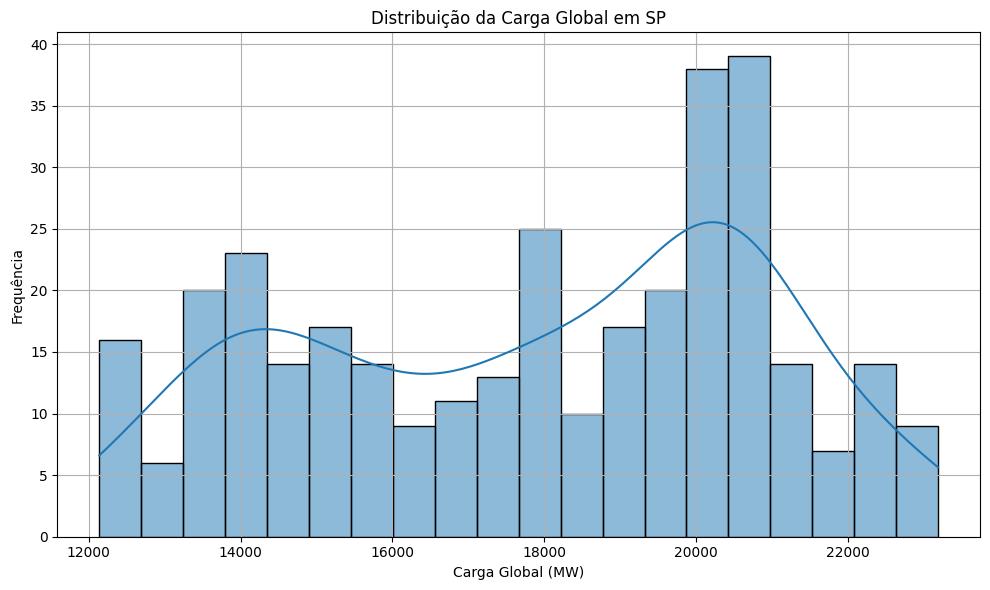

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(df['carga_global'], kde=True, bins=20)
plt.title('Distribuição da Carga Global em SP')
plt.xlabel('Carga Global (MW)')
plt.ylabel('Frequência')
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretação do Gráfico de Distribuição da Carga Global

Este histograma com a curva de densidade de kernel (KDE) nos mostra como os valores da carga global se distribuem. Podemos observar que a maioria das medições de carga se concentra em uma faixa intermediária, com alguns picos (modas) que podem indicar padrões de demanda recorrentes. A cauda à direita da distribuição sugere a existência de períodos de carga mais elevada, correspondendo aos picos de demanda observados no gráfico de série temporal, embora menos frequentes. A distribuição não parece ser perfeitamente simétrica, o que é comum em dados de consumo de energia.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [76]:
resumo_resultados = f'''
Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {df.shape[0]}
Carga mínima: {cargaMin}
Carga máxima: {cargaMax}
Carga média: {cargaMed}
Mediana: {cargaMediana}
Limiar de alta demanda: {limiarAltaDemanda}
Registros de alta demanda: {qtdRegistros_df_altaDemanda}
Percentual de alta demanda: {percentual_df_altaDemanda:.2f}%
Momento do pico: {dataHoraPico}
Segundo critério: Carga acima da média
Registros de carga acima da média: {qtdRegistros_df_acimaMedia}
Percentual de carga acima da média: {percentual_df_acimaMedia:.2f}%
'''

print(resumo_resultados)


Região analisada: SP — São Paulo
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.253
Carga máxima: 23185.312
Carga média: 17870.828980654762
Mediana: 18199.1285
Limiar de alta demanda: 20866.7808
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério: carga acima da média
Registros de carga acima da média: 184
Percentual de carga acima da média: 54.76%



In [73]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [78]:
!pip -q install -U google-genai

In [79]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [80]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [81]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA DE ENERGIA ELÉTRICA**

**Localidade:** Região SP — São Paulo  
**Período de Análise:** 01/08/2025 a 07/08/2025  

---

### 1. Caracterização do Conjunto Analisado
O estudo compreende o monitoramento da carga de energia elétrica na região de São Paulo (SP) durante o período de 01 a 07 de agosto de 2025. A base de dados consolidada para esta análise contempla um total de **336 registros**.

### 2. Principais Indicadores
Os dados estatísticos descritivos da carga no período são apresentados a seguir:

*   **Carga Mínima:** 12.139,253
*   **Carga Máxima (Pico):** 23.185,312
*   **Carga Média:** 17.870,829
*   **Mediana:** 18.199,129
*   **Momento do Pico:** 01/08/2025 às 22:00:00 (UTC+00:00)

*Observação dos dados:* A mediana apresenta-se ligeiramente superior à média populacional do período, indicando uma distribuição de carga levemente deslocada para valores acima do valor médio.

### 3. Análise dos Períodos de Alta Demanda
Para a identificação dos

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA DE ENERGIA ELÉTRICA**

**Localidade:** Região SP — São Paulo  
**Período de Análise:** 01/08/2025 a 07/08/2025  

---

### 1. Caracterização do Conjunto Analisado
O estudo compreende o monitoramento da carga de energia elétrica na região de São Paulo (SP) durante o período de 01 a 07 de agosto de 2025. A base de dados consolidada para esta análise contempla um total de **336 registros**.

### 2. Principais Indicadores
Os dados estatísticos descritivos da carga no período são apresentados a seguir:

*   **Carga Mínima:** 12.139,253
*   **Carga Máxima (Pico):** 23.185,312
*   **Carga Média:** 17.870,829
*   **Mediana:** 18.199,129
*   **Momento do Pico:** 01/08/2025 às 22:00:00 (UTC+00:00)

*Observação dos dados:* A mediana apresenta-se ligeiramente superior à média populacional do período, indicando uma distribuição de carga levemente deslocada para valores acima do valor médio.

### 3. Análise dos Períodos de Alta Demanda
Para a identificação dos momentos de demanda crítica, foi estabelecido um limiar de **20.866,781**.

*   **Registros em alta demanda:** 50
*   **Representatividade:** 14,88% do total de registros analisados.
*   **Pico máximo de demanda:** O ponto máximo absoluto ocorreu no primeiro dia do intervalo analisado (01/08/2025 às 22:00 UTC), atingindo a marca de 23.185,312.

*Nota analítica:* **[Resultado Observado]** A alta demanda concentrou-se em 14,88% do tempo do período analisado. **[Hipótese]** Para determinar os fatores geradores desses 50 eventos de alta demanda e do pico específico às 22:00 (como variáveis meteorológicas ou comportamentais de consumo), seria necessária a integração de bases de dados externas não contidas neste conjunto de dados.

### 4. Comparação com o Segundo Critério
Foi avaliado um segundo critério de classificação operacional: registros em que a **carga esteve acima da média** (superior a 17.870,829).

*   **Registros acima da média:** 184
*   **Representatividade:** 54,76% do total de registros.

**Comparativo entre os critérios:**
*   **Critério de Alta Demanda (Limiar 20.866,781):** Filtra os eventos de ponta/extremos, representando **14,88%** da amostra (50 registros).
*   **Critério Carga Acima da Média (Limiar 17.870,829):** Abrange a maioria dos registros do período, englobando **54,76%** da amostragem (184 registros).

### 5. Conclusão
Com base exclusivamente nos dados fornecidos:
1. O sistema operou com uma amplitude de carga de 11.046,059 unidades entre o menor registro (12.139,253) e o maior registro (23.185,312).
2. Em mais da metade do tempo analisado (54,76%), a carga permaneceu acima da média calculada de 17.870,829.
3. Os regimes de alta demanda (definidos acima de 20.866,781) têm caráter mais restrito, ocorrendo em 14,88% do período, tendo seu ponto máximo registrado no dia 01/08/2025 às 22:00:00 UTC.

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?  
  R: Sim

2. Há alguma afirmação que não pode ser confirmada pelos dados?  
  R: Não, Gemini explicitou que para confirmar sua hipotese ele precisaria de dados que não estão presentes nesse conjunto de dados.

3. Houve interpretação exagerada ou causalidade não demonstrada?  
  R: Não.

4. Que alterações a equipe realizou no texto?  
  R: Houve a inclusão de análise dos gráficos, padrão de comportamento observado e uma conclusão adicional.

## Relatório final

Insira abaixo a versão final revisada pela equipe.

**RELATÓRIO TÉCNICO FINAL DA ANÁLISE DE CARGA DE ENERGIA ELÉTRICA**

**Localidade:** Região SP — São Paulo  
**Período de Análise:** 01/08/2025 a 07/08/2025  

---

### 1. Caracterização do Conjunto Analisado
O estudo compreende o monitoramento da carga de energia elétrica na região de São Paulo (SP) durante o período de 01 a 07 de agosto de 2025. A base de dados consolidada para esta análise contempla um total de **336 registros**, com medições a cada 30 minutos.

### 2. Principais Indicadores da Carga Elétrica
Os dados estatísticos descritivos da carga global no período são apresentados a seguir:

*   **Carga Mínima:** 12.139,253 MW
*   **Carga Máxima (Pico):** 23.185,312 MW
*   **Carga Média:** 17.870,829 MW
*   **Mediana:** 18.199,129 MW
*   **Amplitude (Máx - Mín):** 11.046,059 MW

*Observação dos dados:* A mediana (18.199,129 MW) apresenta-se ligeiramente superior à carga média (17.870,829 MW), indicando uma distribuição de carga levemente deslocada para valores acima da média. A carga máxima está aproximadamente 29,7% acima da carga média, destacando-se como um ponto de demanda significativamente mais alta, mas ainda dentro de variações esperadas em sistemas elétricos.

### 3. Análise dos Períodos de Alta Demanda
Para a identificação dos momentos de demanda crítica, foi estabelecido um limiar de **20.866,781 MW** (90% da carga máxima).

*   **Registros em Alta Demanda:** 50
*   **Representatividade:** 14,88% do total de registros analisados.
*   **Pico Máximo de Demanda:** O ponto máximo absoluto ocorreu no primeiro dia do intervalo analisado (01/08/2025 às 22:00:00 UTC), atingindo a marca de 23.185,312 MW.

*Nota analítica:* Os períodos de alta demanda representam uma parcela pequena, porém crítica, do período analisado. A análise visual do gráfico de comportamento da carga ao longo do tempo confirma a ocorrência de picos diários, com o dia 01/08/2025 apresentando o maior pico. O Box Plot por hora do dia mostra que as cargas mais elevadas tendem a ocorrer no final da tarde e início da noite, alinhando-se com o momento do pico identificado.

### 4. Comparação com o Segundo Critério: Carga Acima da Média
Foi avaliado um segundo critério de classificação operacional: registros em que a **carga esteve acima da média** (superior a 17.870,829 MW).

*   **Registros Acima da Média:** 184
*   **Representatividade:** 54,76% do total de registros.

**Comparativo entre os critérios:**
*   **Critério de Alta Demanda (Limiar 20.866,781 MW):** Filtra os eventos de ponta/extremos, representando **14,88%** da amostra (50 registros).
*   **Critério Carga Acima da Média (Limiar 17.870,829 MW):** Abrange a maioria dos registros do período, englobando **54,76%** da amostragem (184 registros).

O critério de "carga acima da média" é mais abrangente, pois inclui todos os períodos onde a demanda superou o comportamento usual, sendo menos restritivo que o critério de "alta demanda". Isso é refletido em seu maior percentual de representatividade.

### 5. Padrões de Consumo e Distribuição

*   **Comportamento Temporal:** O gráfico de série temporal (Carga Global ao Longo do Tempo) revela padrões diários claros, com vales nas madrugadas e picos durante o dia e a noite. Também se observa uma variação semanal, com alguns dias apresentando picos mais proeminentes. Não há anomalias evidentes que destoem do comportamento cíclico esperado.
*   **Distribuição da Carga:** O histograma com KDE da carga global mostra uma distribuição bimodal ou multimodal, com concentrações de frequência em faixas de carga intermediárias e mais altas, confirmando a existência de diferentes regimes de demanda. A distribuição não é perfeitamente simétrica, com uma cauda para valores mais altos, indicando a presença de picos.
*   **Padrão Horário:** O Box Plot da Carga Global por Hora do Dia demonstra uma elevação consistente da carga a partir das primeiras horas da manhã, atingindo um patamar elevado entre as 10h e 22h, e caindo na madrugada. A variabilidade da carga (dispersão) também é notável em algumas horas, com alguns outliers que representam eventos pontuais de carga muito alta ou baixa para aquela hora específica.

### 6. Conclusão
Com base exclusivamente nos dados fornecidos:
1.  O sistema operou com uma amplitude de carga de 11.046,059 MW, variando entre 12.139,253 MW e 23.185,312 MW.
2.  Em mais da metade do tempo analisado (54,76%), a carga permaneceu acima da média calculada de 17.870,829 MW.
3.  Os regimes de alta demanda (definidos acima de 90% da carga máxima) são mais restritos, ocorrendo em 14,88% do período, com o pico máximo registrado no dia 01/08/2025 às 22:00:00 UTC.
4.  Os padrões diários e horários de consumo são evidentes, com picos de demanda concentrados em horários específicos do dia, indicando a necessidade de monitoramento e planejamento para gerenciar esses períodos de maior exigência no sistema elétrico.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**